In [1]:
import numpy as np
import matplotlib.pyplot as plt

print("NumPy:", np.__version__)

NumPy: 2.5.3


In [2]:
np.random.seed(8)

city = "Полтава"

base_temp = 8.5
amplitude = 14
base_consumption = 1100
k = 28
noise_sd = 30

months = np.arange(1, 13)

month_names = [
    "Січ", "Лют", "Бер", "Кві",
    "Тра", "Чер", "Лип", "Сер",
    "Вер", "Жов", "Лис", "Гру"
]

temp = base_temp + amplitude * np.cos(
    (months - 7) / 12 * 2 * np.pi
)

temp = np.round(
    temp + np.random.normal(0, 0.5, size=12),
    1
)

consumption = (
    base_consumption
    - k * (temp - base_temp)
    + np.random.normal(0, noise_sd, size=12)
)

consumption = np.round(consumption, 0)

print("Місто:", city)
print("Температура:", temp)
print("Споживання:", consumption)

Місто: Полтава
Температура: [-5.5 -3.1  0.5  7.8 14.4 21.8 23.4 21.7 15.9  9.   0.9 -2.7]
Споживання: [1458. 1405. 1313. 1096.  961.  721.  681.  724.  933. 1068. 1308. 1426.]


In [3]:
print("Дані Полтави")
print("-" * 60)
print(
    f"{'Місяць':<10}"
    f"{'Температура':>15}"
    f"{'Споживання':>18}"
)
print("-" * 60)

for i in range(12):
    print(
        f"{month_names[i]:<10}"
        f"{temp[i]:>15.1f}"
        f"{consumption[i]:>18.0f}"
    )

Дані Полтави
------------------------------------------------------------
Місяць        Температура        Споживання
------------------------------------------------------------
Січ                  -5.5              1458
Лют                  -3.1              1405
Бер                   0.5              1313
Кві                   7.8              1096
Тра                  14.4               961
Чер                  21.8               721
Лип                  23.4               681
Сер                  21.7               724
Вер                  15.9               933
Жов                   9.0              1068
Лис                   0.9              1308
Гру                  -2.7              1426


In [4]:
b, a = np.polyfit(
    temp,
    consumption,
    1
)

prediction = a + b * temp

print(
    f"споживання ≈ {a:.1f} + ({b:.1f}) · температура"
)

споживання ≈ 1327.4 + (-27.2) · температура


In [5]:
residuals = consumption - prediction

print("-" * 80)
print(
    f"{'Місяць':<10}"
    f"{'Темп.':>10}"
    f"{'Спостережено':>18}"
    f"{'Передбачено':>18}"
    f"{'Залишок':>15}"
)
print("-" * 80)

for i in range(12):
    print(
        f"{month_names[i]:<10}"
        f"{temp[i]:>10.1f}"
        f"{consumption[i]:>18.0f}"
        f"{prediction[i]:>18.1f}"
        f"{residuals[i]:>15.1f}"
    )

--------------------------------------------------------------------------------
Місяць         Темп.      Спостережено       Передбачено        Залишок
--------------------------------------------------------------------------------
Січ             -5.5              1458            1477.1          -19.1
Лют             -3.1              1405            1411.8           -6.8
Бер              0.5              1313            1313.7           -0.7
Кві              7.8              1096            1115.0          -19.0
Тра             14.4               961             935.3           25.7
Чер             21.8               721             733.8          -12.8
Лип             23.4               681             690.3           -9.3
Сер             21.7               724             736.5          -12.5
Вер             15.9               933             894.5           38.5
Жов              9.0              1068            1082.3          -14.3
Лис              0.9              1308        

In [6]:
ss_res = np.sum(residuals ** 2)

ss_tot = np.sum(
    (consumption - np.mean(consumption)) ** 2
)

r_squared = 1 - ss_res / ss_tot

print(f"R² = {r_squared:.4f}")
print(f"R² = {r_squared * 100:.2f}%")

R² = 0.9955
R² = 99.55%


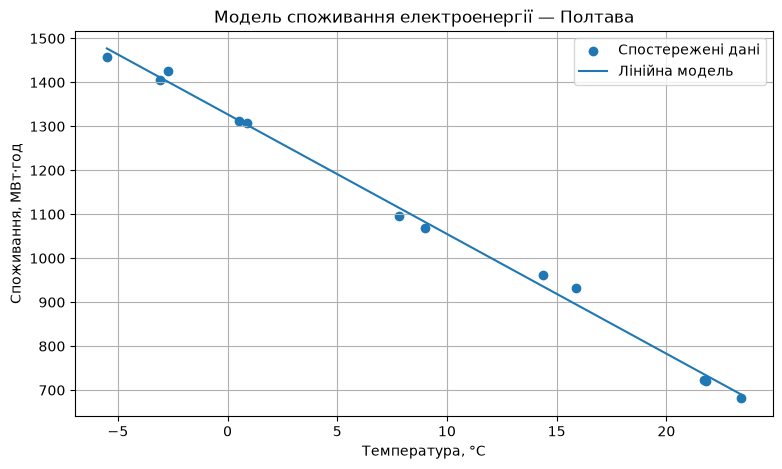

In [7]:
plt.figure(figsize=(9, 5))

plt.scatter(
    temp,
    consumption,
    label="Спостережені дані"
)

order = np.argsort(temp)

plt.plot(
    temp[order],
    prediction[order],
    label="Лінійна модель"
)

plt.xlabel("Температура, °C")
plt.ylabel("Споживання, МВт·год")
plt.title("Модель споживання електроенергії — Полтава")

plt.grid(True)
plt.legend()

plt.show()

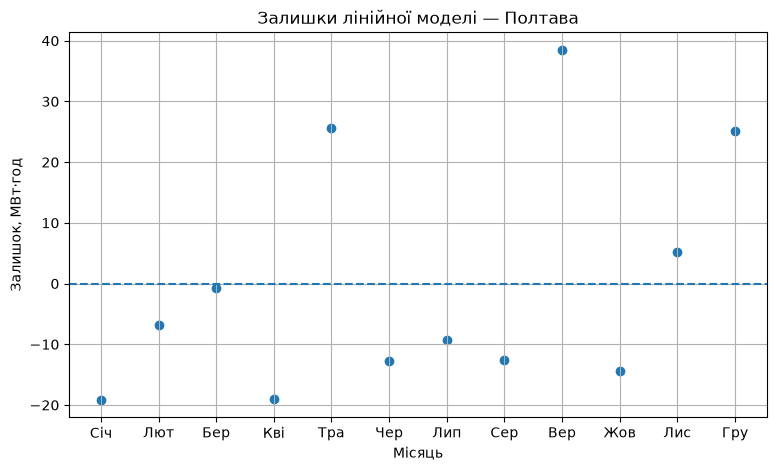

In [8]:
plt.figure(figsize=(9, 5))

plt.axhline(
    0,
    linestyle="--"
)

plt.scatter(
    months,
    residuals
)

plt.xticks(
    months,
    month_names
)

plt.xlabel("Місяць")
plt.ylabel("Залишок, МВт·год")
plt.title("Залишки лінійної моделі — Полтава")

plt.grid(True)

plt.show()